# Calculate Depth
Some Clearwater-Modules require depth.

## Import Paths

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import xarray as xr


import clearwater_riverine as cwr
from clearwater_riverine.utilities import calculate_wetted_surface_area
from clearwater_riverine.variables import VOLUME_ELEVATION_LOOKUP, WATER_SURFACE_ELEVATION

## Model Set Up

In [3]:
project_path = Path.cwd().parent
src_path = project_path / 'src'
print(project_path)
print(src_path)

#point to config
network_path = Path(r'W:\2ERDC12 - Clearwater\Clearwater_testing_NSM\plan_48_simulation')
wetted_surface_area_path = network_path / "wetted_surface_area.zarr"
q_solar_path = network_path / 'cwr_boundary_conditions_q_solar_p28.csv'
air_temp_path = network_path / 'cwr_boundary_conditions_TairC_p28.csv'
config_file = network_path / 'demo_config.yml'
print(config_file.exists())

start_index =  0 # int((8*60*60)/30)
end_index = 48*60*60
print(start_index, end_index)

transport_model = cwr.ClearwaterRiverine(
    config_filepath=config_file,
    verbose=True,
    datetime_range= (start_index, end_index)
)

C:\Users\sjordan\OneDrive - LimnoTech\Documents\GitHub\clearwater-riverine\examples
C:\Users\sjordan\OneDrive - LimnoTech\Documents\GitHub\clearwater-riverine\examples\src
True
0 172800
Populating Model Mesh...
Calculating Required Parameters...


## Calculate Wetted Surface Area

This function will calculate the wetted surface area. I'm not doing this by default because it's not necessary for advection-diffusion (i.e., ClearWater-Riverine). The following calculation is trivial, but I could see it taking longer or using more memory for a very large grid. 

In [4]:
calculate_wetted_surface_area(
    transport_model.mesh
)

In [5]:
# confirm
transport_model.mesh.wetted_surface_area

<xarray.DataArray 'wetted_surface_area' (time: 5761, nface: 444)>
array([[ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       ...,
       [ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan]])
Coordinates:
  * time     (time) datetime64[ns] 2022-05-13 2022-05-13T00:00:30 ... 2022-05-15
    face_x   (nface) float64 5.005e+05 5.006e+05 ... 5.005e+05 5.024e+05
    face_y   (nface) float64 2.45e+03 2.45e+03 2.45e+03 ... 2.5e+03 500.0 564.4
  * nface    (nface) int64 0 1 2 3 4 5 6 7 8 ... 436 437 438 439 440 441 442 443

## Calculate Max Depth

In [28]:
minimum_elevation = (
    transport_model.mesh.attrs[VOLUME_ELEVATION_LOOKUP]
    .groupby("Cell")["Elevation"]
    .min()
    .to_xarray()
    .rename({"Cell": "nface"})
    .reindex(nface=transport_model.mesh.nface) # volume elevation lookup only has real cells
)

In [29]:
minimum_elevation

<xarray.DataArray 'Elevation' (nface: 444)>
array([22.2431469 , 22.22241974, 22.25838661, 22.2358036 , 22.2285099 ,
       22.22573471, 22.23459053, 22.24713898, 22.25868607, 22.28529358,
       22.3415432 , 22.43881416, 23.04117012, 23.37302017, 23.73606873,
       24.        , 24.        , 24.        , 24.        , 24.        ,
       21.56411934, 21.87594032, 22.12050438, 22.34791946, 23.18852234,
       23.6696682 , 24.        , 24.        , 21.8936367 , 22.33468819,
       23.05201721, 23.55800056, 22.69664764, 22.93482971, 23.09185219,
       23.23578644, 23.0816021 , 22.84630013, 22.12915421, 22.83100891,
       23.23524094, 23.539505  , 23.74722862, 22.65881157, 22.81491661,
       23.20066071, 23.93845367, 23.59212303, 23.23755074, 22.81267738,
       22.18893623, 22.26033401, 23.85393333, 22.53602409, 21.48028183,
       23.37065887, 24.        , 24.        , 24.        , 23.91320992,
       22.36624146, 21.20257187, 22.03445053, 22.77758598, 21.11364555,
       23.38123322, 23.53554535, 23.62403488, 23.3149128 , 22.7228756 ,
       21.82376289, 20.6624794 , 20.        , 22.19304657, 22.29817772,
       22.83776474, 22.53484154, 22.48187256, 22.39389229, 22.17218399,
       21.24002075, 22.06419563, 21.44142342, 21.52737999, 23.05121994,
       24.        , 22.94496346, 22.19484138, 22.48468208, 23.15480804,
       22.84249878, 22.35636711, 23.07979584, 23.89064407, 21.41959   ,
       22.24183083, 22.63697433, 22.85911369, 23.50870323, 24.        ,
...
       24.        , 24.        , 22.95845985, 24.        , 24.        ,
       24.        , 24.        , 24.        , 24.        , 24.        ,
       23.2672863 , 21.98374939, 24.        , 24.        , 24.        ,
       24.        , 24.        , 22.64168167, 24.        , 24.        ,
       24.        , 24.        ,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan])
Coordinates:
  * nface    (nface) int64 0 1 2 3 4 5 6 7 8 ... 436 437 438 439 440 441 442 443

In [30]:
elevation = transport_model.mesh[WATER_SURFACE_ELEVATION] - minimum_elevation

### Investigate how this looks

Pick a cell that increases in volume over time. Does the elevation also increase over time?

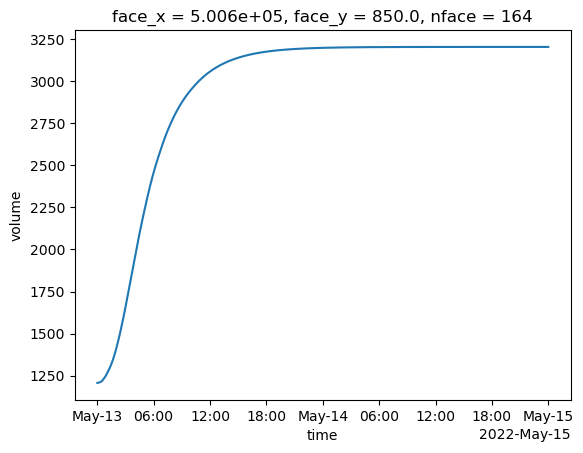

In [38]:
transport_model.mesh.volume.isel(nface=164).plot()

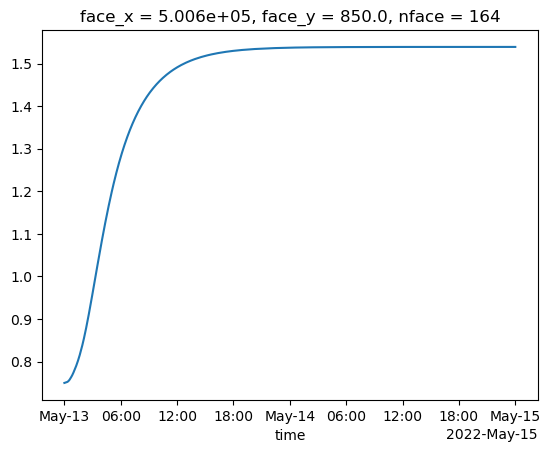

In [33]:
elevation.isel(nface=164).plot()

Looking good so far. Now confirm that the max depth looks about right from the lookup table:

In [34]:
lookup_df = transport_model.mesh.attrs['volume_elevation_lookup']

In [35]:
lookup_df[lookup_df.Cell == 164]

,Elevation,Volume,Cell,Delta Elev,Delta Volume,Surface Area,Wetted Surface Area,lookup
0,20.000000,0.000000,164.0,NaN,NaN,NaN,0.000000,0
1,20.131800,169.350540,164.0,0.131800,169.350540,1284.908447,1352.558350,1
2,20.275583,373.553162,164.0,0.143784,204.202621,1420.208374,1494.562622,2
3,20.419365,599.134644,164.0,0.143782,225.581482,1568.916870,1643.639771,3
4,20.551165,825.614319,164.0,0.131800,226.479675,1718.362671,1792.567627,4
5,20.682966,1071.657959,164.0,0.131802,246.043640,1866.772705,1944.272583,5
6,20.814766,1338.126953,164.0,0.131800,266.468994,2021.772461,2102.249512,6
7,20.946568,1625.813843,164.0,0.131802,287.686890,2182.726807,2266.022949,7
8,21.078367,1935.453369,164.0,0.131800,309.639526,2349.318848,2430.582520,8
9,21.198187,2236.421875,164.0,0.119820,300.968506,2511.846191,2597.468750,9


Take a look at the max depth:

In [36]:
23.055374 - 20

3.0553740000000005

Our max volume is ~1.5, which is much less than this... but do we achieve the max volume?

In [37]:
transport_model.mesh.volume.isel(nface=164).max()

<xarray.DataArray 'volume' ()>
array(3203.60131836)
Coordinates:
    face_x   float64 5.006e+05
    face_y   float64 850.0
    nface    int64 164

No, the max volume puts us right around 1.5 m depth as well. I think this looks about right. 